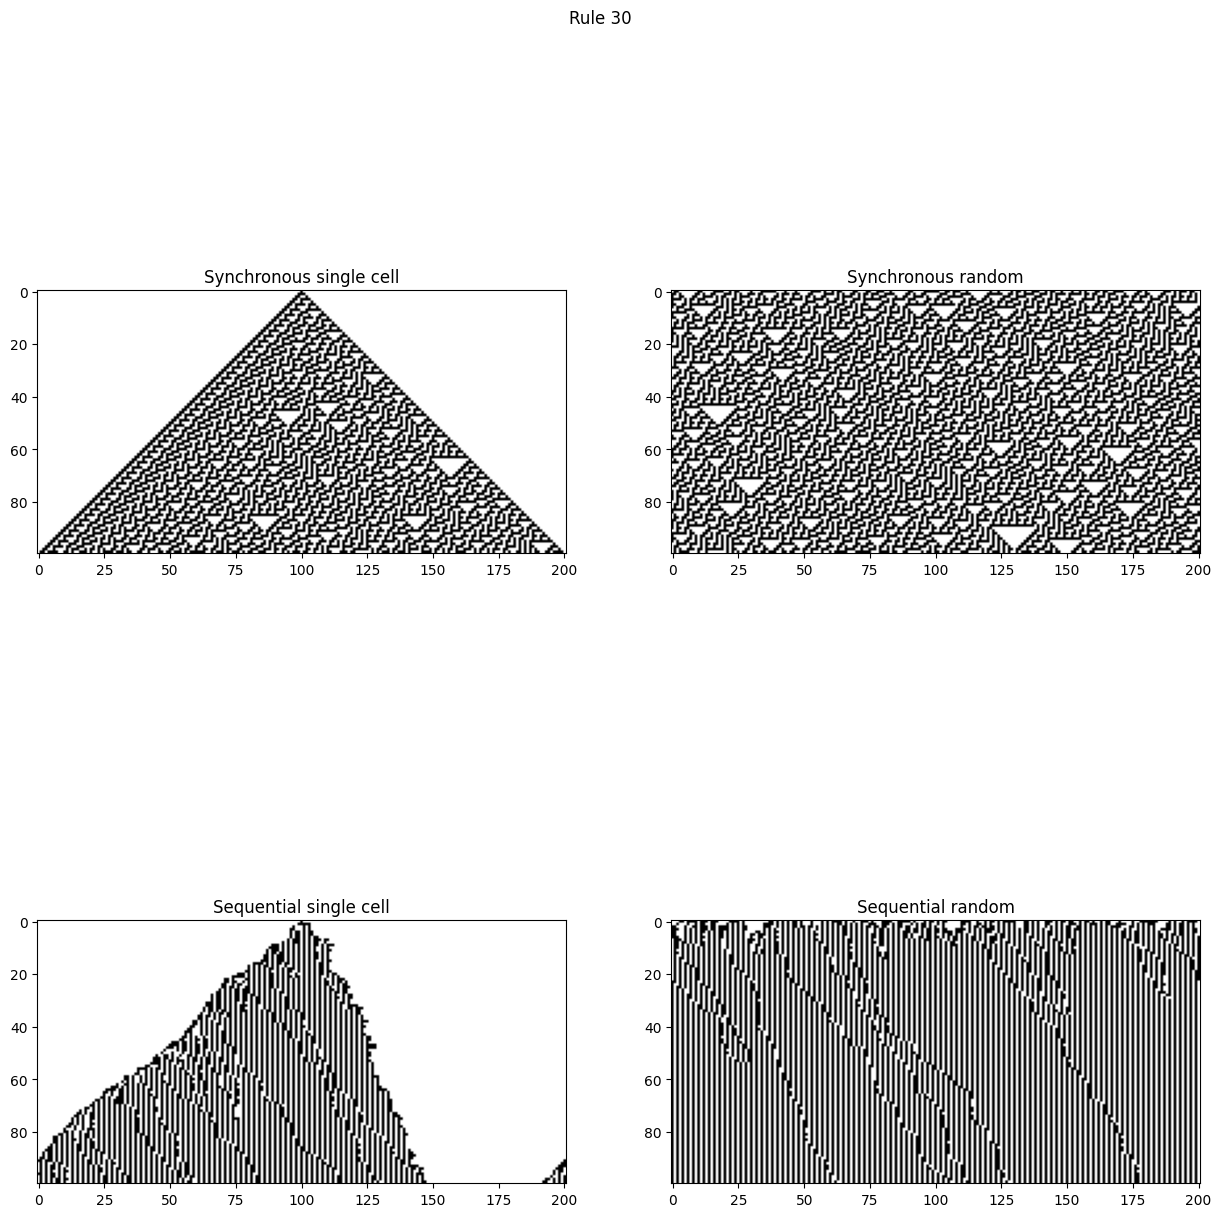

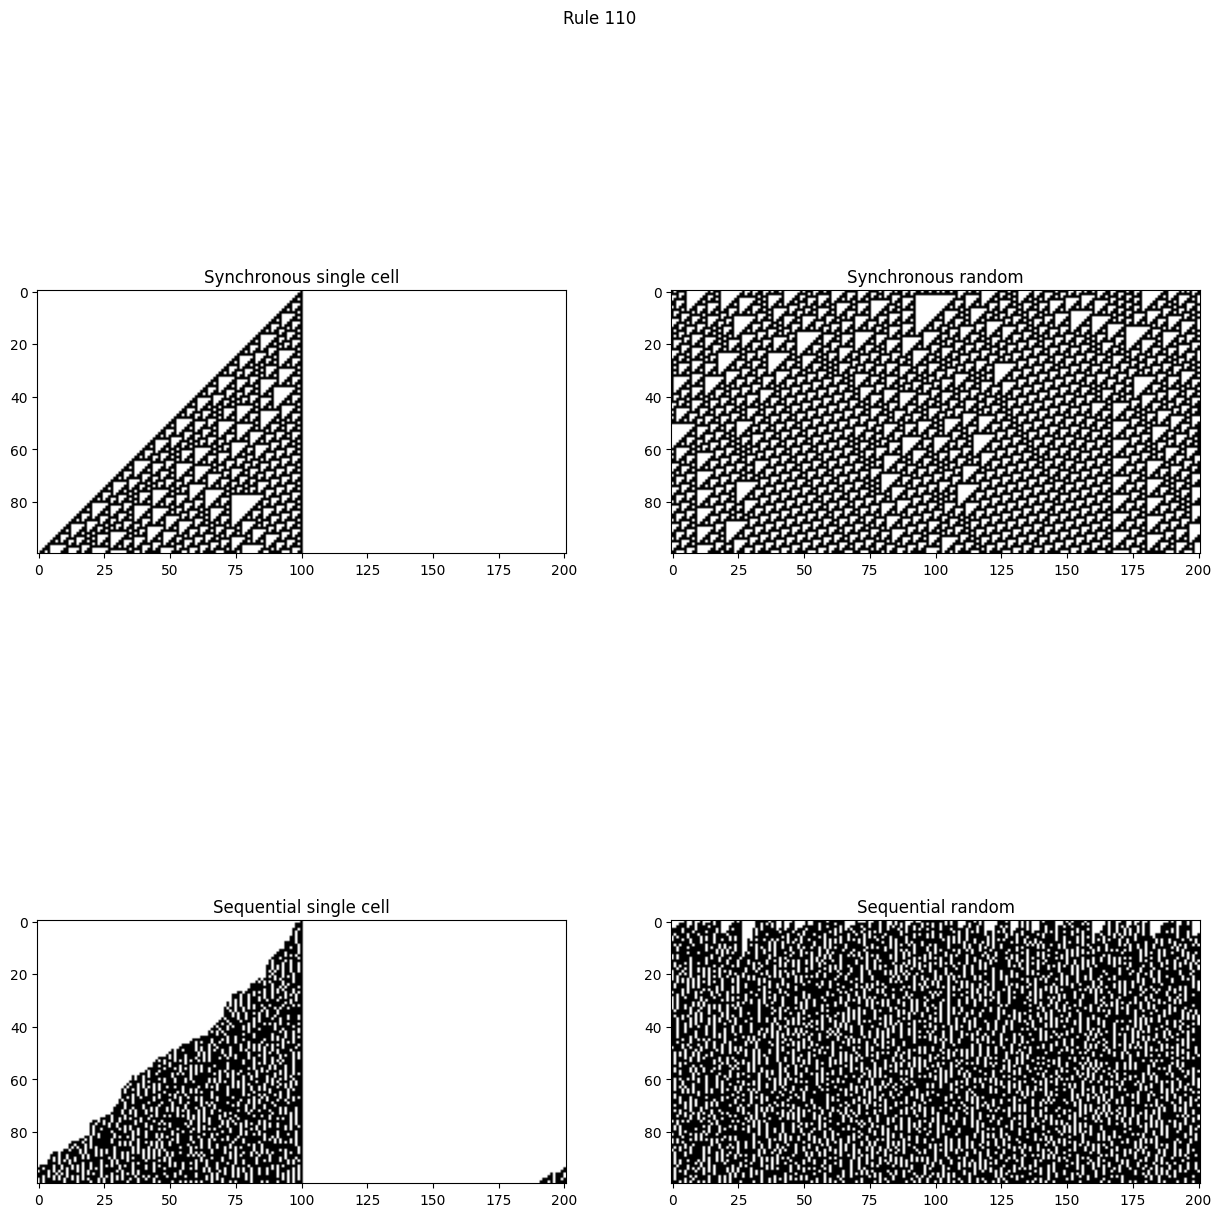

In [1]:
# wolfram elementary cellular automata

import numpy as np
import matplotlib.pyplot as plt

# cellular automata rules
def rules_30(c_1, c_2, c_3):
    if c_1 == 1 and c_2 == 1 and c_3 == 1: 
        return 0
    elif c_1 == 1 and c_2 == 1 and c_3 == 0: 
        return 0
    elif c_1 == 1 and c_2 == 0 and c_3 == 1: 
        return 0
    elif c_1 == 1 and c_2 == 0 and c_3 == 0: 
        return 1
    elif c_1 == 0 and c_2 == 1 and c_3 == 1: 
        return 1
    elif c_1 == 0 and c_2 == 1 and c_3 == 0: 
        return 1
    elif c_1 == 0 and c_2 == 0 and c_3 == 1: 
        return 1
    elif c_1 == 0 and c_2 == 0 and c_3 == 0: 
        return 0

def rules_110(c_1, c_2, c_3):
    if c_1 == 1 and c_2 == 1 and c_3 == 1: 
        return 0
    elif c_1 == 1 and c_2 == 1 and c_3 == 0: 
        return 1
    elif c_1 == 1 and c_2 == 0 and c_3 == 1: 
        return 1
    elif c_1 == 1 and c_2 == 0 and c_3 == 0: 
        return 0
    elif c_1 == 0 and c_2 == 1 and c_3 == 1: 
        return 1
    elif c_1 == 0 and c_2 == 1 and c_3 == 0: 
        return 1
    elif c_1 == 0 and c_2 == 0 and c_3 == 1: 
        return 1
    elif c_1 == 0 and c_2 == 0 and c_3 == 0: 
        return 0

# updating rule table
def update(cells, L, rule_type):
    new_cells = np.zeros(L)
    for i in range(L):
        if i == 0:
            c_1 = cells[L-1]
            c_3 = cells[i+1]
        elif i == L-1:
            c_1 = cells[i-1]
            c_3 = cells[0]
        else:
            c_1 = cells[i-1]
            c_3 = cells[i+1]
        
        c_2 = cells[i]
        
        if rule_type == 30:
            new_cells[i] = rules_30(c_1, c_2, c_3)
        elif rule_type == 110:
            new_cells[i] = rules_110(c_1, c_2, c_3)
            
    return new_cells

def update_seq(cells, L, rule_type):
    new_cells = cells.copy() # making copies to preserve original array
    for _ in range(L):
        i = np.random.randint(0, L)
        
        if i == 0:
            c_1 = new_cells[L-1]
            c_3 = new_cells[i+1]
        elif i == L-1:
            c_1 = new_cells[i-1]
            c_3 = new_cells[0]
        else:
            c_1 = new_cells[i-1]
            c_3 = new_cells[i+1]
            
        c_2 = new_cells[i]
        
        if rule_type == 30:
            new_cells[i] = rules_30(c_1, c_2, c_3)
        elif rule_type == 110:
            new_cells[i] = rules_110(c_1, c_2, c_3)
            
    return new_cells

# running the simulation
L = 201 # <-- # of cells
T = 100 # <-- # of steps

for rule in [30, 110]:
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    fig.suptitle(f"Rule {rule}")
    
    # synchronus single cell
    cells_1 = np.zeros(L)
    cells_1[L//2] = 1
    collect_1 = np.zeros((T, L))
    collect_1[0] = cells_1
    for t in range(1, T):
        cells_1 = update(cells_1, L, rule)
        collect_1[t] = cells_1
    axes[0, 0].imshow(collect_1, cmap='binary')
    axes[0, 0].set_title("Synchronous single cell")
    
    # synchronus random
    cells_2 = np.random.randint(2, size=L)
    collect_2 = np.zeros((T, L))
    collect_2[0] = cells_2
    for t in range(1, T):
        cells_2 = update(cells_2, L, rule)
        collect_2[t] = cells_2
    axes[0, 1].imshow(collect_2, cmap='binary')
    axes[0, 1].set_title("Synchronous random")
    
    # sequential single cell
    cells_3 = np.zeros(L)
    cells_3[L//2] = 1
    collect_3 = np.zeros((T, L))
    collect_3[0] = cells_3
    for t in range(1, T):
        cells_3 = update_seq(cells_3, L, rule)
        collect_3[t] = cells_3
    axes[1, 0].imshow(collect_3, cmap='binary')
    axes[1, 0].set_title("Sequential single cell")
    
    # sequential random
    cells_4 = np.random.randint(2, size=L)
    collect_4 = np.zeros((T, L))
    collect_4[0] = cells_4
    for t in range(1, T):
        cells_4 = update_seq(cells_4, L, rule)
        collect_4[t] = cells_4
    axes[1, 1].imshow(collect_4, cmap='binary')
    axes[1, 1].set_title("Sequential random")

    plt.show()

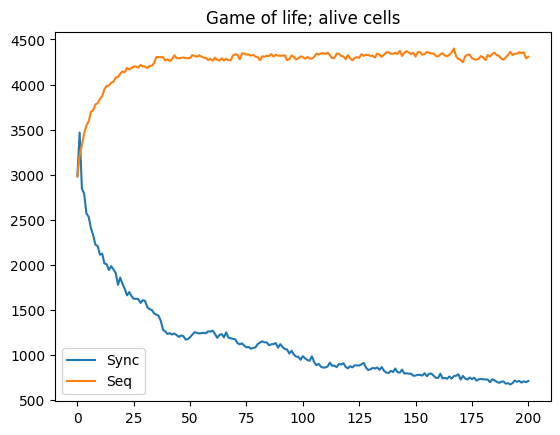

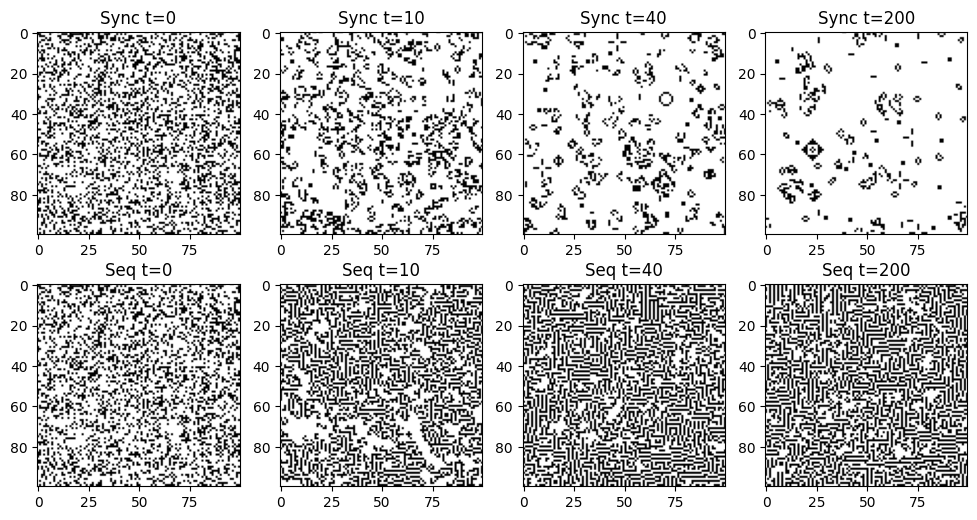

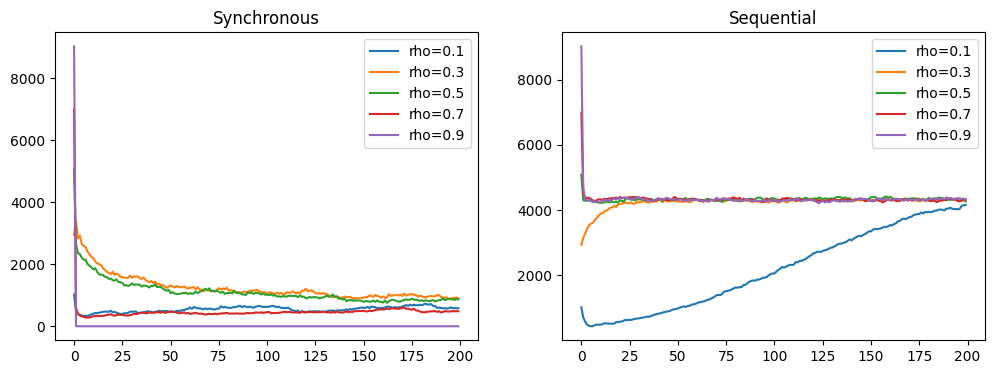

In [2]:
# conway's game of life

def count_neighbors(cells, i, j, L):
    if i == 0: up = L - 1
    else: up = i - 1
        
    if i == L - 1: down = 0
    else: down = i + 1
        
    if j == 0: left = L - 1
    else: left = j - 1
        
    if j == L - 1: right = 0
    else: right = j + 1
        
    # sum
    total = 0
    total += cells[up, left]
    total += cells[up, j]
    total += cells[up, right]
    total += cells[i, left]
    total += cells[i, right]
    total += cells[down, left]
    total += cells[down, j]
    total += cells[down, right]
    
    return total

def gol_sync(cells, L):
    new_cells = np.zeros((L, L))
    for i in range(L):
        for j in range(L):
            n = count_neighbors(cells, i, j, L)
            if cells[i, j] == 1:
                if n == 2 or n == 3:
                    new_cells[i, j] = 1
                else:
                    new_cells[i, j] = 0
            else:
                if n == 3:
                    new_cells[i, j] = 1
    return new_cells

def gol_seq(cells, L):
    new_cells = cells.copy()
    for _ in range(L * L): # there are L*L random updates in a single time step
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        
        n = count_neighbors(new_cells, i, j, L)
        if new_cells[i, j] == 1:
            if n < 2 or n > 3:
                new_cells[i, j] = 0
        else:
            if n == 3:
                new_cells[i, j] = 1
    return new_cells

# simulation run
L = 100 # <-- # of cells
T = 200 # <-- # of steps
rho_0 = 0.3 # <-- p[0]

# grid initialization for the simulation to run properly
initial_grid = np.random.choice([0, 1], size=(L, L), p=[1-rho_0, rho_0])

grid_sync = initial_grid.copy()
grid_seq = initial_grid.copy()

N_sync = []
N_seq = []

sync_snaps = []
seq_snaps = []

for t in range(T + 1):
    N_sync.append(np.sum(grid_sync))
    N_seq.append(np.sum(grid_seq))
    
    if t == 0 or t == 10 or t == 40 or t == 200:
        sync_snaps.append(grid_sync.copy())
        seq_snaps.append(grid_seq.copy())
        
    grid_sync = gol_sync(grid_sync, L)
    grid_seq = gol_seq(grid_seq, L)

plt.plot(N_sync, label="Sync")
plt.plot(N_seq, label="Seq")
plt.legend()
plt.title("Game of life; alive cells")
plt.show() # time series plot

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
times = [0, 10, 40, 200]
for idx in range(4):
    axes[0, idx].imshow(sync_snaps[idx], cmap='binary')
    axes[0, idx].set_title(f"Sync t={times[idx]}")
    
    axes[1, idx].imshow(seq_snaps[idx], cmap='binary')
    axes[1, idx].set_title(f"Seq t={times[idx]}")
plt.show() # snapshot plot

# ===================================================
#                   differnt densities
# ===================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
densities = [0.1, 0.3, 0.5, 0.7, 0.9]

for rho in densities:
    g_sync = np.random.choice([0, 1], size=(L, L), p=[1-rho, rho])
    g_seq = g_sync.copy()
    
    n_s = []
    n_q = []
    
    for t in range(T):
        n_s.append(np.sum(g_sync))
        n_q.append(np.sum(g_seq))
        g_sync = gol_sync(g_sync, L)
        g_seq = gol_seq(g_seq, L)
        
    ax1.plot(n_s, label=f"rho={rho}")
    ax2.plot(n_q, label=f"rho={rho}")

ax1.set_title("Synchronous")
ax1.legend()
ax2.set_title("Sequential")
ax2.legend()
plt.show()

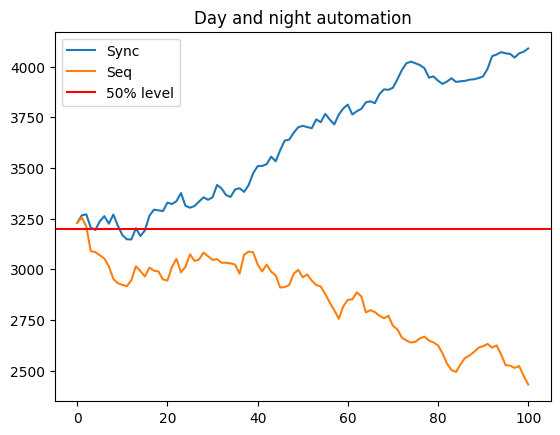

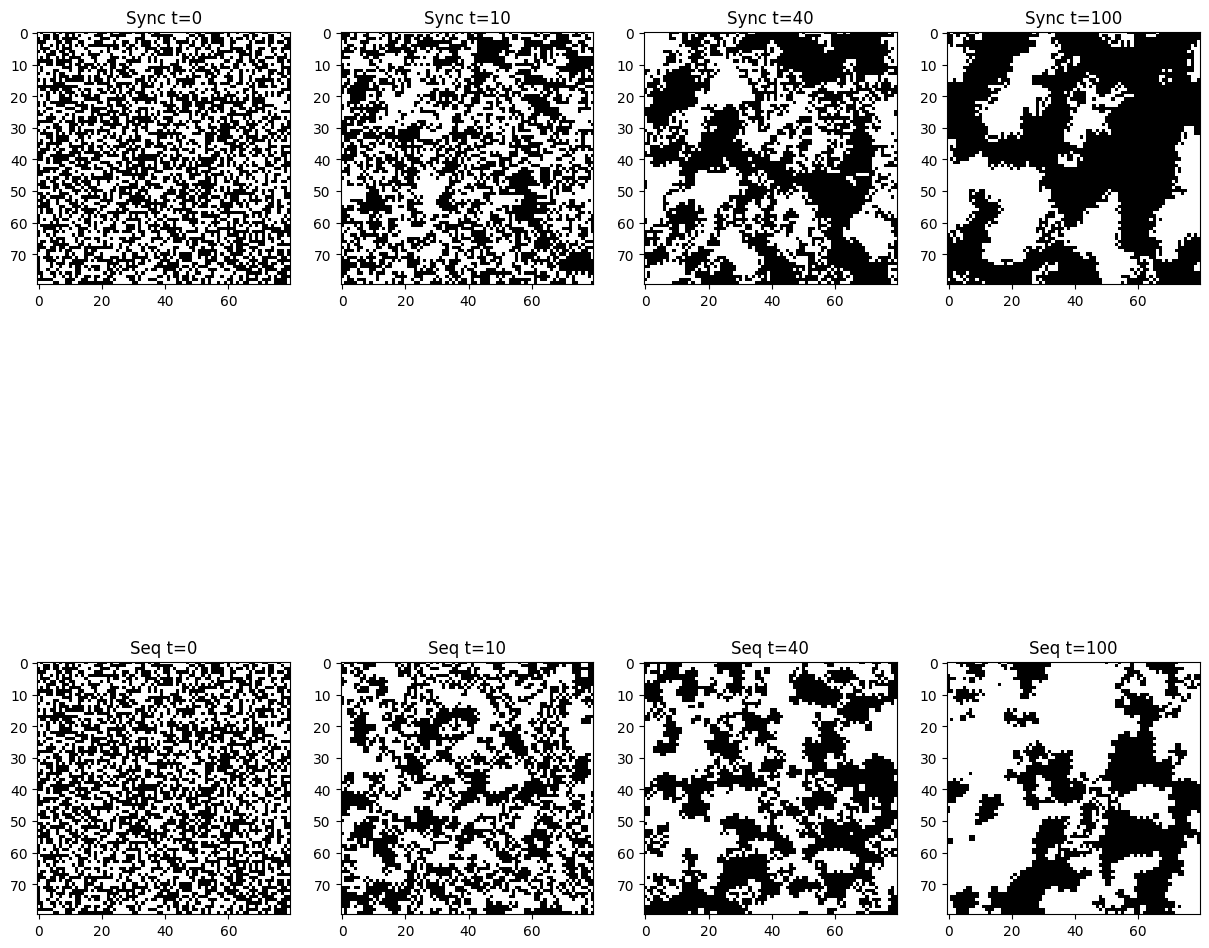

In [3]:
# day and night automation

def dan_sync(cells, L):
    new_cells = np.zeros((L, L))
    for i in range(L):
        for j in range(L):
            n = count_neighbors(cells, i, j, L)
            if cells[i, j] == 1:
                if n == 3 or n == 4 or n == 6 or n == 7 or n == 8:
                    new_cells[i, j] = 1
                else:
                    new_cells[i, j] = 0
            else:
                if n == 3 or n == 6 or n == 7 or n == 8:
                    new_cells[i, j] = 1
    return new_cells

def dan_seq(cells, L):
    new_cells = cells.copy()
    for _ in range(L * L):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        
        n = count_neighbors(new_cells, i, j, L)
        if new_cells[i, j] == 1:
            if n == 3 or n == 4 or n == 6 or n == 7 or n == 8:
                pass # if it survives, it stays at value 1!
            else:
                new_cells[i, j] = 0
        else:
            if n == 3 or n == 6 or n == 7 or n == 8:
                new_cells[i, j] = 1
    return new_cells

# running the simulation
L = 80 # <-- # of cells
T = 100 # <-- # of steps
rho_0 = 0.5 # <-- p[0]

initial_grid = np.random.choice([0, 1], size=(L, L), p=[1-rho_0, rho_0])

grid_sync = initial_grid.copy()
grid_seq = initial_grid.copy()

N_sync = []
N_seq = []

sync_snaps = []
seq_snaps = []

for t in range(T + 1):
    N_sync.append(np.sum(grid_sync))
    N_seq.append(np.sum(grid_seq))
    
    if t in [0, 10, 40, 100]:
        sync_snaps.append(grid_sync.copy())
        seq_snaps.append(grid_seq.copy())
        
    grid_sync = dan_sync(grid_sync, L)
    grid_seq = dan_seq(grid_seq, L)

plt.plot(N_sync, label="Sync")
plt.plot(N_seq, label="Seq")
plt.axhline(y=(L*L)*0.5, color='red', label="50% level")
plt.legend()
plt.title("Day and night automation")
plt.show() # time series plot

fig, axes = plt.subplots(2, 4, figsize=(15, 15))
times = [0, 10, 40, 100]
for idx in range(4):
    axes[0, idx].imshow(sync_snaps[idx], cmap='binary')
    axes[0, idx].set_title(f"Sync t={times[idx]}")
    
    axes[1, idx].imshow(seq_snaps[idx], cmap='binary')
    axes[1, idx].set_title(f"Seq t={times[idx]}")
plt.show() # snapshot plot